Fetching data for AAPL and comps …
  Revenue  : $451.4B
  EBITDA   : $160.0B
  Price    : $293.32

════════════════════════════════════════════════════════════
  VALUATION REPORT — AAPL
════════════════════════════════════════════════════════════

  Current Price    : $    293.32
  Market Cap       : $   4,308.1B
  Enterprise Value : $   4,323.4B
  EV/EBITDA        :     27.025
  Trailing P/E     :  35.467957

  ─── DCF IMPLIED PRICES ──────────────────────────────
╭────────────┬───────────────────┬─────────────────┬────────────────────╮
│ Scenario   │ Implied EV ($B)   │ Implied Price   │ Premium/Discount   │
├────────────┼───────────────────┼─────────────────┼────────────────────┤
│ Bull       │ $2340.1B          │ $158.23         │ -46.1%             │
│ Base       │ $1826.7B          │ $123.27         │ -58.0%             │
│ Bear       │ $1416.0B          │ $95.31          │ -67.5%             │
╰────────────┴───────────────────┴─────────────────┴────────────────────╯

  ─── COMPS

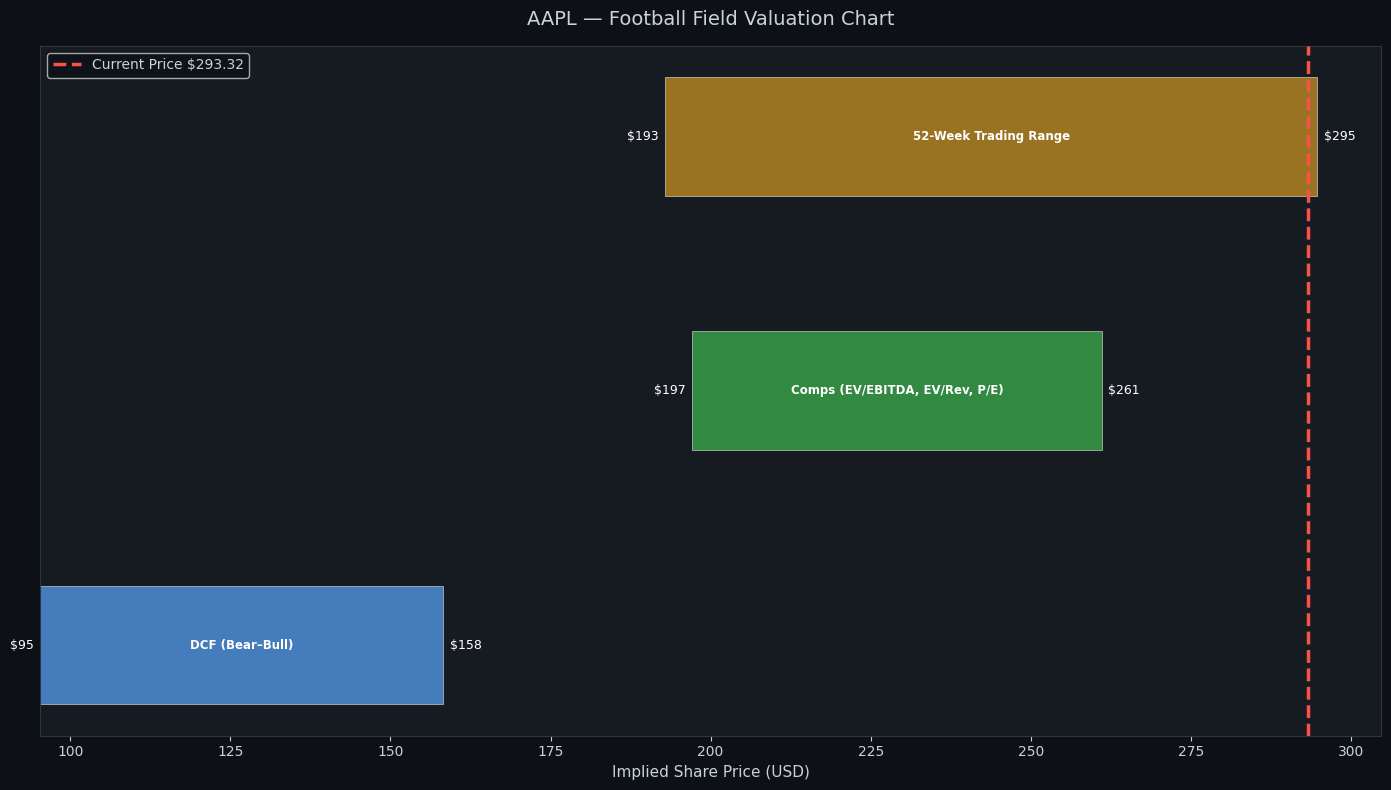


  Chart saved → valuation_football_field.png

Done ✓


In [3]:
"""
DCF + Comparable Company Valuation Model
==========================================
A full investment-banking style valuation of any public company.
  • Discounted Cash Flow (DCF) with sensitivity table
  • Comparable company (comps) analysis
  • Football field chart — all methods side by side
  • Scenario analysis (Bull / Base / Bear)
  • Output: PDF-quality chart + summary table

Requirements:
    pip install yfinance pandas numpy matplotlib scipy tabulate
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ─────────────────────────────────────────────────────────────────────
TARGET_TICKER  = "AAPL"
COMPS_TICKERS  = ["MSFT", "GOOGL", "META", "AMZN"]

# DCF assumptions (you can edit these)
PROJECTION_YEARS  = 5
WACC              = 0.09      # Weighted average cost of capital
TERMINAL_GROWTH   = 0.025     # Long-term perpetuity growth rate
TAX_RATE          = 0.21

# Scenario revenue growth assumptions (yr1 → yr5)
SCENARIOS = {
    "Bull":  [0.18, 0.16, 0.14, 0.12, 0.10],
    "Base":  [0.10, 0.09, 0.08, 0.07, 0.06],
    "Bear":  [0.04, 0.03, 0.02, 0.01, 0.00],
}

EBITDA_MARGIN   = 0.315   # assumed stable
DA_RATE         = 0.04    # D&A as % of revenue
CAPEX_RATE      = 0.045   # Capex as % of revenue
NWC_CHANGE_RATE = 0.01    # change in NWC as % of revenue
# ───────────────────────────────────────────────────────────────────────────────


def fetch_financials(ticker):
    t = yf.Ticker(ticker)
    info = t.info

    # Pull key metrics with safe fallbacks
    revenue       = info.get("totalRevenue",        None)
    ebitda        = info.get("ebitda",              None)
    net_income    = info.get("netIncomeToCommon",   None)
    total_debt    = info.get("totalDebt",           0)
    cash          = info.get("totalCash",           0)
    shares_out    = info.get("sharesOutstanding",   None)
    price         = info.get("currentPrice",        info.get("regularMarketPrice", None))
    ev            = info.get("enterpriseValue",     None)
    pe            = info.get("trailingPE",          None)
    fwd_pe        = info.get("forwardPE",           None)
    ev_ebitda     = info.get("enterpriseToEbitda",  None)
    ev_revenue    = info.get("enterpriseToRevenue", None)

    return {
        "ticker":      ticker,
        "revenue":     revenue,
        "ebitda":      ebitda,
        "net_income":  net_income,
        "total_debt":  total_debt,
        "cash":        cash,
        "shares_out":  shares_out,
        "price":       price,
        "ev":          ev,
        "pe":          pe,
        "fwd_pe":      fwd_pe,
        "ev_ebitda":   ev_ebitda,
        "ev_revenue":  ev_revenue,
    }


def run_dcf(base_revenue, scenario_growth_rates, wacc=WACC,
            terminal_g=TERMINAL_GROWTH):
    revenues, fcfs, pv_fcfs = [], [], []
    rev = base_revenue

    for i, g in enumerate(scenario_growth_rates):
        rev        = rev * (1 + g)
        ebitda     = rev * EBITDA_MARGIN
        ebit       = ebitda - rev * DA_RATE
        nopat      = ebit * (1 - TAX_RATE)
        da         = rev * DA_RATE
        capex      = rev * CAPEX_RATE
        nwc_change = rev * NWC_CHANGE_RATE
        fcf        = nopat + da - capex - nwc_change

        revenues.append(rev)
        fcfs.append(fcf)
        pv_fcfs.append(fcf / (1 + wacc) ** (i + 1))

    # Terminal value (Gordon Growth)
    terminal_fcf = fcfs[-1] * (1 + terminal_g)
    tv           = terminal_fcf / (wacc - terminal_g)
    pv_tv        = tv / (1 + wacc) ** PROJECTION_YEARS

    enterprise_value = sum(pv_fcfs) + pv_tv
    return enterprise_value, revenues, fcfs, pv_fcfs, pv_tv


def equity_value_per_share(ev, debt, cash, shares):
    return (ev - debt + cash) / shares


def sensitivity_table(base_revenue, debt, cash, shares,
                       wacc_range, tg_range):
    rows = []
    for tg in tg_range:
        row = []
        for wacc in wacc_range:
            ev, *_ = run_dcf(base_revenue, SCENARIOS["Base"],
                             wacc=wacc, terminal_g=tg)
            price = equity_value_per_share(ev, debt, cash, shares)
            row.append(round(price, 1))
        rows.append(row)
    return pd.DataFrame(rows,
                        index=[f"{t*100:.1f}%" for t in tg_range],
                        columns=[f"{w*100:.1f}%" for w in wacc_range])


def comps_analysis(comp_data, target):
    """Derive implied EV and price from peer medians."""
    ev_ebitda_peers = [d["ev_ebitda"] for d in comp_data if d["ev_ebitda"]]
    ev_rev_peers    = [d["ev_revenue"] for d in comp_data if d["ev_revenue"]]
    pe_peers        = [d["pe"]        for d in comp_data if d["pe"]]

    median_ev_ebitda = np.median(ev_ebitda_peers)
    median_ev_rev    = np.median(ev_rev_peers)
    median_pe        = np.median(pe_peers)

    impl_ev_from_ebitda = target["ebitda"] * median_ev_ebitda if target["ebitda"] else None
    impl_ev_from_rev    = target["revenue"] * median_ev_rev   if target["revenue"] else None
    impl_price_pe       = (target["net_income"] / target["shares_out"]) * median_pe \
                          if target["net_income"] and target["shares_out"] else None

    def to_price(ev):
        if ev is None: return None
        return equity_value_per_share(ev, target["total_debt"], target["cash"], target["shares_out"])

    return {
        "median_ev_ebitda":      round(median_ev_ebitda, 2),
        "median_ev_revenue":     round(median_ev_rev, 2),
        "median_pe":             round(median_pe, 2),
        "implied_price_ebitda":  round(to_price(impl_ev_from_ebitda) or 0, 2),
        "implied_price_revenue": round(to_price(impl_ev_from_rev) or 0, 2),
        "implied_price_pe":      round(impl_price_pe or 0, 2),
    }


def print_full_report(target, scenario_results, comps, sens_df):
    print("\n" + "═"*60)
    print(f"  VALUATION REPORT — {target['ticker']}")
    print("═"*60)

    # Current market data
    mkt_cap = (target["price"] or 0) * (target["shares_out"] or 0)
    print(f"\n  Current Price    : ${target['price']:>10,.2f}")
    print(f"  Market Cap       : ${mkt_cap/1e9:>10,.1f}B")
    print(f"  Enterprise Value : ${(target['ev'] or 0)/1e9:>10,.1f}B")
    print(f"  EV/EBITDA        : {target['ev_ebitda'] or 'N/A':>10}")
    print(f"  Trailing P/E     : {target['pe'] or 'N/A':>10}")

    # DCF scenarios
    print("\n  ─── DCF IMPLIED PRICES ──────────────────────────────")
    headers = ["Scenario", "Implied EV ($B)", "Implied Price", "Premium/Discount"]
    rows = []
    for sc, (ev, *_) in scenario_results.items():
        price_impl = equity_value_per_share(ev, target["total_debt"],
                                            target["cash"], target["shares_out"])
        prem = ((price_impl / target["price"]) - 1) * 100 if target["price"] else 0
        rows.append([sc, f"${ev/1e9:.1f}B", f"${price_impl:.2f}", f"{prem:+.1f}%"])
    print(tabulate(rows, headers=headers, tablefmt="rounded_outline"))

    # Comps
    print("\n  ─── COMPS IMPLIED PRICES ────────────────────────────")
    print(f"  Peer EV/EBITDA median   : {comps['median_ev_ebitda']:.1f}x  → "
          f"${comps['implied_price_ebitda']:.2f}")
    print(f"  Peer EV/Revenue median  : {comps['median_ev_revenue']:.1f}x  → "
          f"${comps['implied_price_revenue']:.2f}")
    print(f"  Peer P/E median         : {comps['median_pe']:.1f}x  → "
          f"${comps['implied_price_pe']:.2f}")

    # Sensitivity
    print("\n  ─── SENSITIVITY TABLE (Base Case) ───────────────────")
    print("  Rows = Terminal Growth Rate | Cols = WACC\n")
    print(tabulate(sens_df, headers="keys", tablefmt="rounded_outline"))


def plot_football_field(target, scenario_results, comps):
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#161b22")

    current = target["price"]

    ranges = []

    # DCF ranges
    dcf_prices = []
    for sc, (ev, *_) in scenario_results.items():
        p = equity_value_per_share(ev, target["total_debt"], target["cash"], target["shares_out"])
        dcf_prices.append(p)
    ranges.append(("DCF (Bear–Bull)", min(dcf_prices), max(dcf_prices), "#58a6ff"))

    # Comps ranges
    comp_prices = [comps["implied_price_ebitda"],
                   comps["implied_price_revenue"],
                   comps["implied_price_pe"]]
    comp_prices = [p for p in comp_prices if p > 0]
    if comp_prices:
        ranges.append(("Comps (EV/EBITDA, EV/Rev, P/E)", min(comp_prices), max(comp_prices), "#3fb950"))

    # 52-week range
    t     = yf.Ticker(target["ticker"])
    hist  = t.history(period="1y")
    if not hist.empty:
        lo52 = hist["Low"].min()
        hi52 = hist["High"].max()
        ranges.append(("52-Week Trading Range", lo52, hi52, "#d29922"))

    # Plot horizontal bars
    for i, (label, lo, hi, color) in enumerate(ranges):
        y = i * 1.5
        ax.barh(y, hi - lo, left=lo, height=0.7,
                color=color, alpha=0.7, edgecolor="white", linewidth=0.5)
        ax.text(lo - 1, y, f"${lo:.0f}", ha="right", va="center",
                color="white", fontsize=9)
        ax.text(hi + 1, y, f"${hi:.0f}", ha="left", va="center",
                color="white", fontsize=9)
        ax.text((lo + hi) / 2, y, label, ha="center", va="center",
                color="white", fontsize=8.5, fontweight="bold")

    # Current price line
    ax.axvline(current, color="#f85149", linewidth=2.5, linestyle="--",
               label=f"Current Price ${current:.2f}", zorder=5)

    ax.set_yticks([])
    ax.set_xlabel("Implied Share Price (USD)", color="#c9d1d9", fontsize=11)
    ax.set_title(f"{target['ticker']} — Football Field Valuation Chart",
                 color="#c9d1d9", fontsize=14, pad=15)
    ax.tick_params(colors="#c9d1d9")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.legend(facecolor="#0d1117", labelcolor="#c9d1d9", fontsize=10)

    plt.tight_layout()
    plt.savefig("valuation_football_field.png", dpi=150, bbox_inches="tight",
                facecolor="#0d1117")
    plt.show()
    print("\n  Chart saved → valuation_football_field.png")


def main():
    print(f"Fetching data for {TARGET_TICKER} and comps …")
    target    = fetch_financials(TARGET_TICKER)
    comp_data = [fetch_financials(t) for t in COMPS_TICKERS]

    if not target["revenue"]:
        print("ERROR: Could not fetch revenue data. Try a different ticker.")
        return

    print(f"  Revenue  : ${target['revenue']/1e9:.1f}B")
    print(f"  EBITDA   : ${(target['ebitda'] or 0)/1e9:.1f}B")
    print(f"  Price    : ${target['price']:.2f}")

    # Run DCF for each scenario
    scenario_results = {}
    for sc, growth in SCENARIOS.items():
        ev, revenues, fcfs, pv_fcfs, pv_tv = run_dcf(target["revenue"], growth)
        scenario_results[sc] = (ev, revenues, fcfs, pv_fcfs, pv_tv)

    # Comps
    comps = comps_analysis(comp_data, target)

    # Sensitivity
    wacc_range = [0.07, 0.08, 0.09, 0.10, 0.11]
    tg_range   = [0.015, 0.020, 0.025, 0.030, 0.035]
    sens_df    = sensitivity_table(target["revenue"], target["total_debt"],
                                   target["cash"], target["shares_out"],
                                   wacc_range, tg_range)

    print_full_report(target, scenario_results, comps, sens_df)
    plot_football_field(target, scenario_results, comps)
    print("\nDone ✓")


if __name__ == "__main__":
    main()